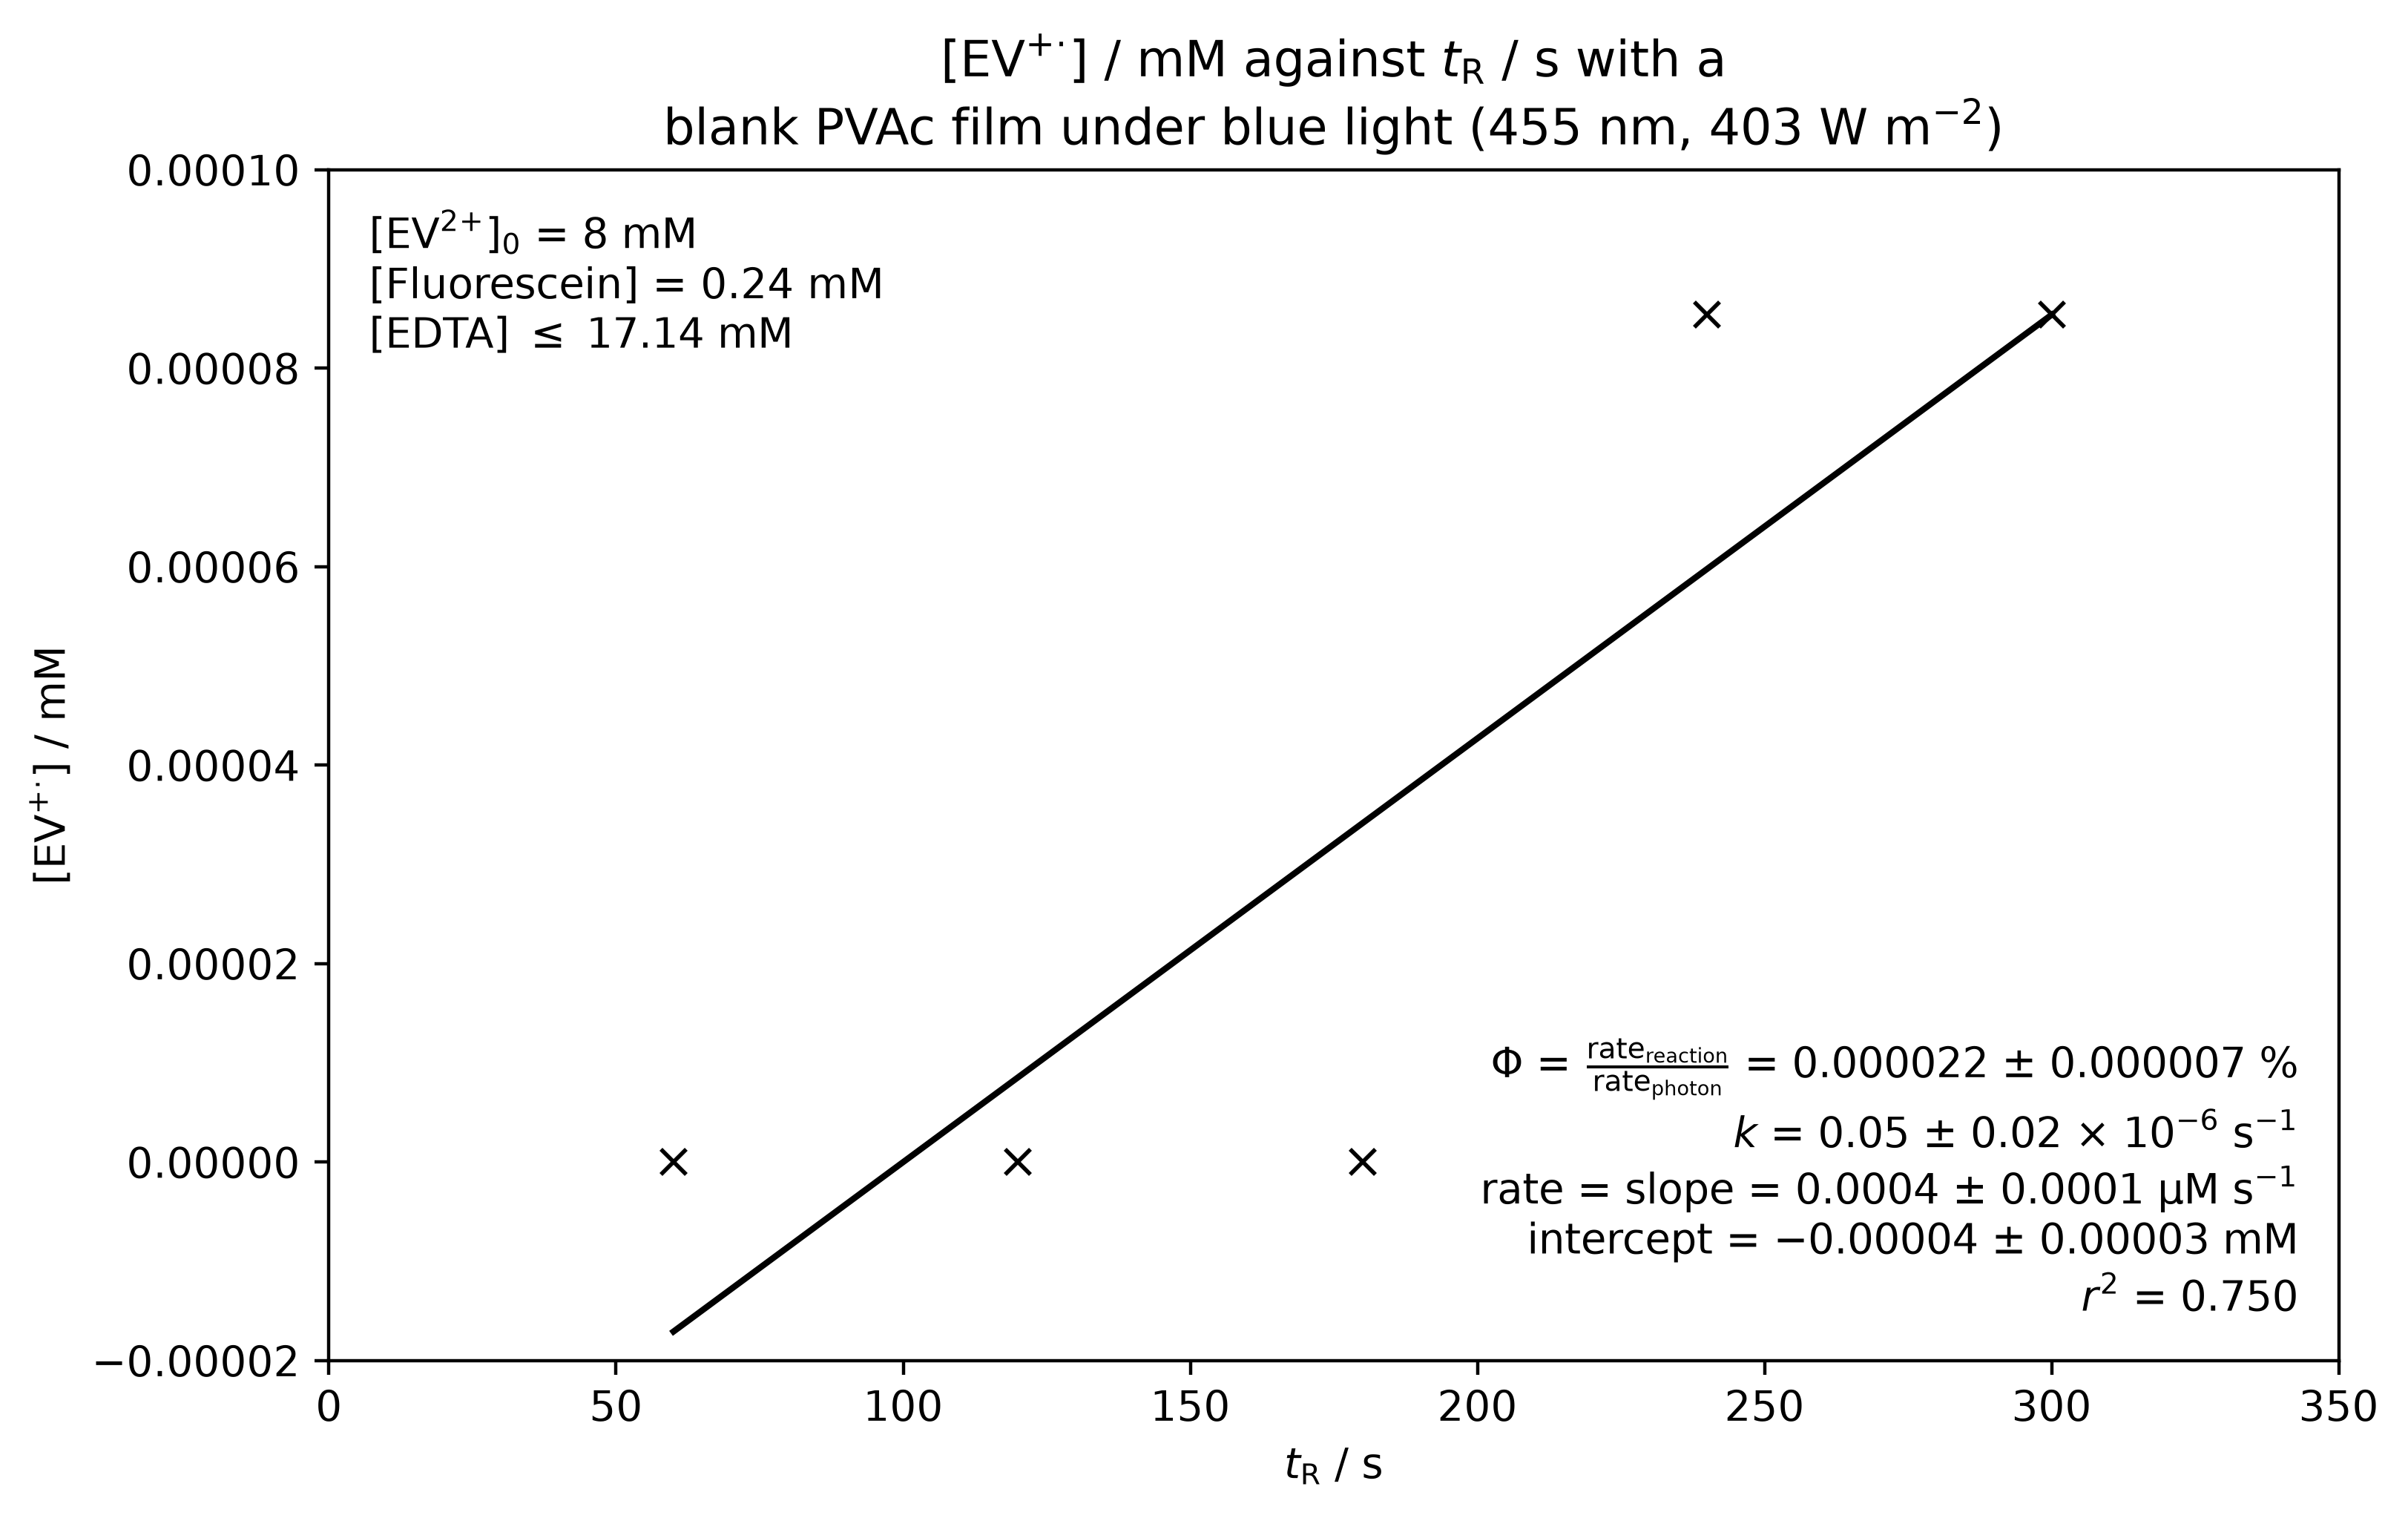

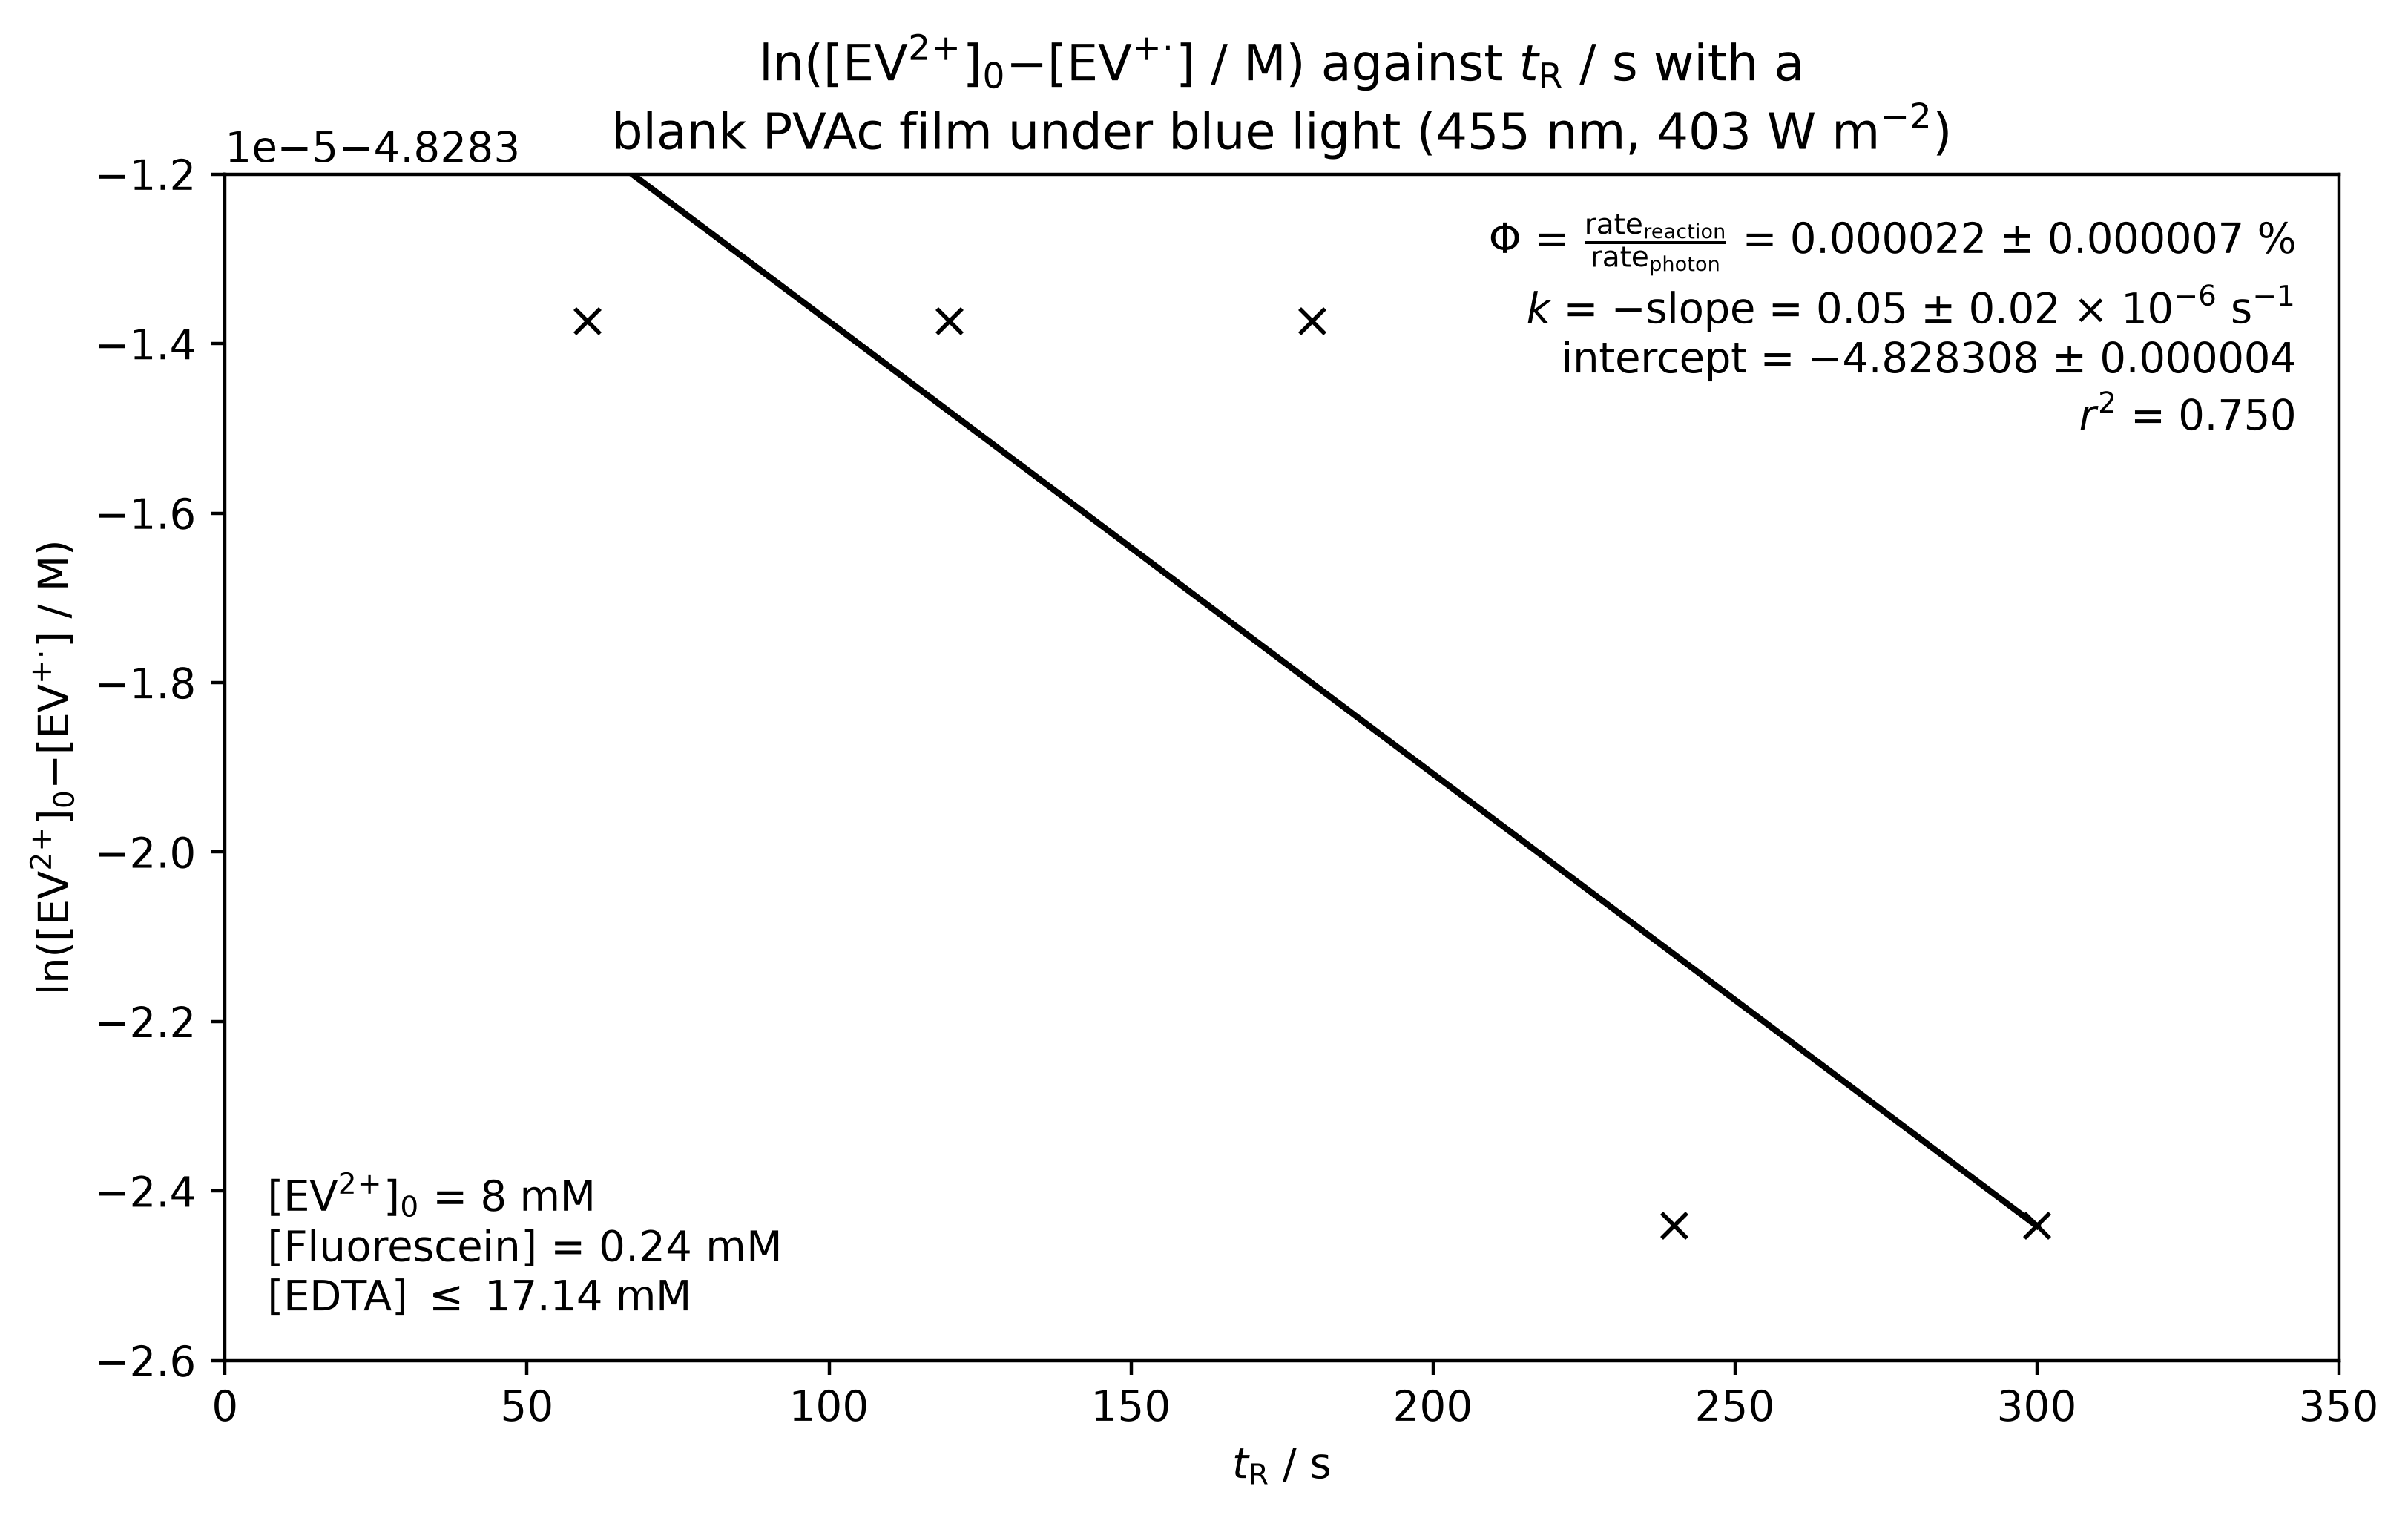

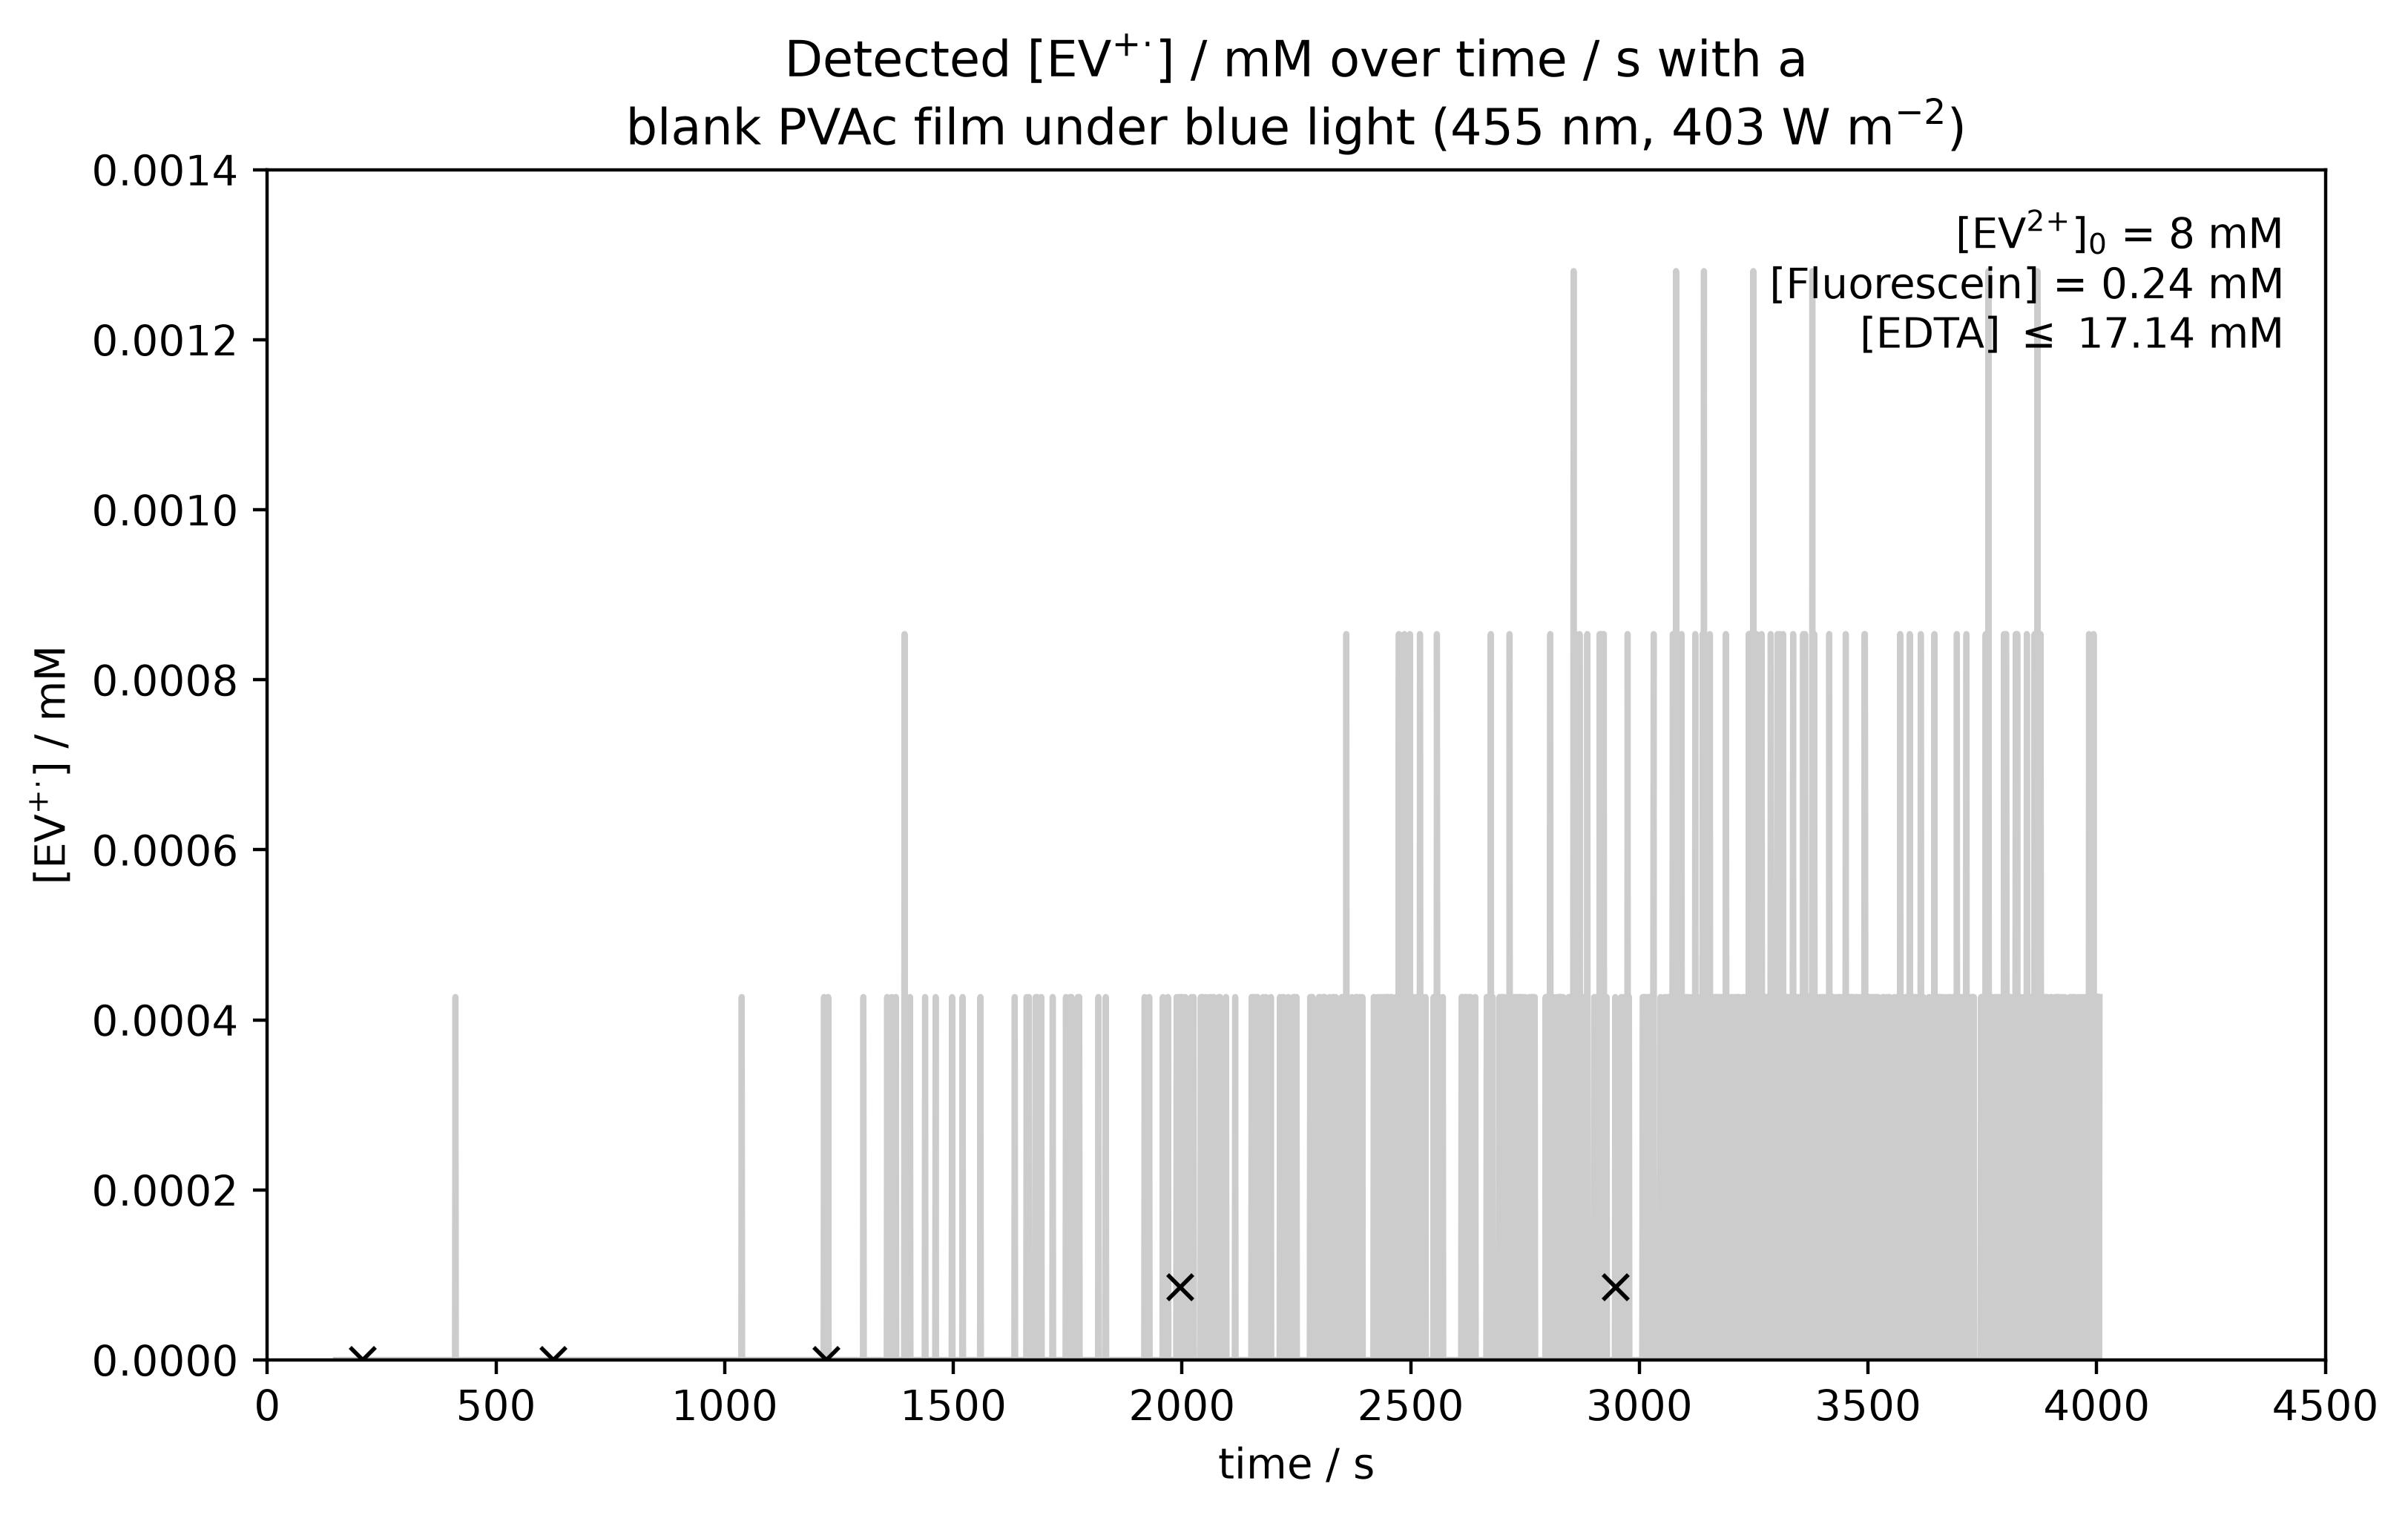

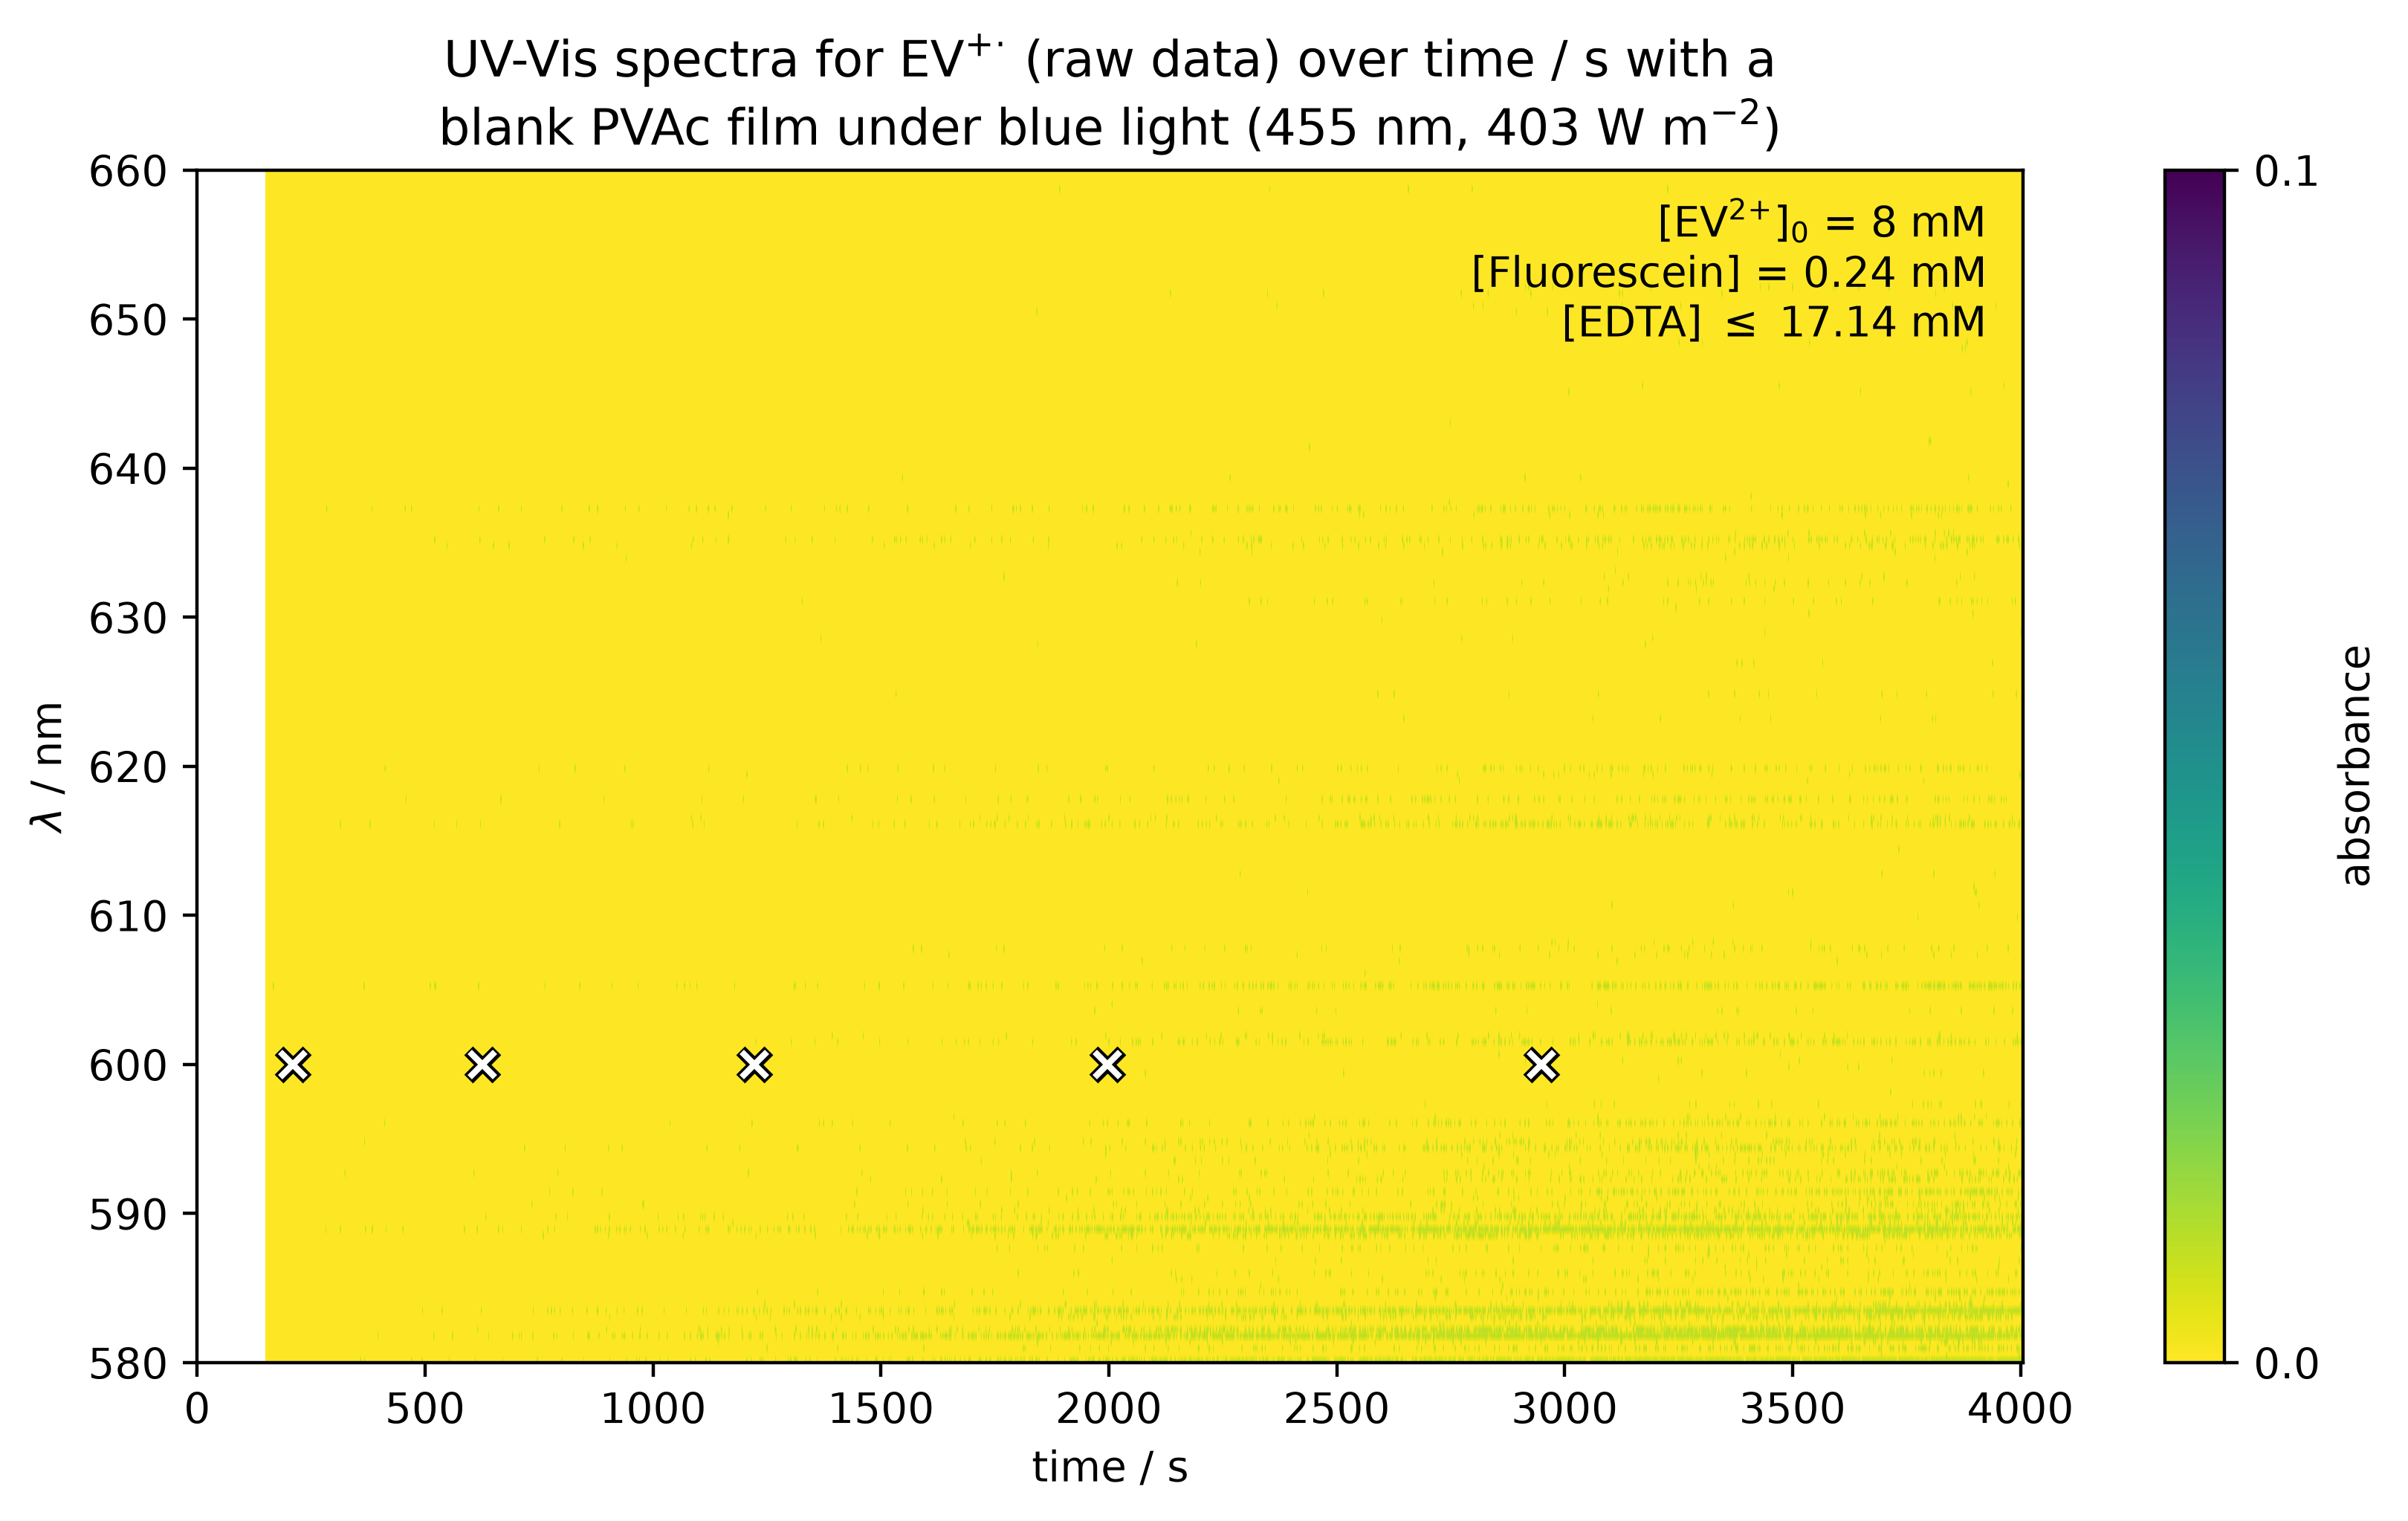

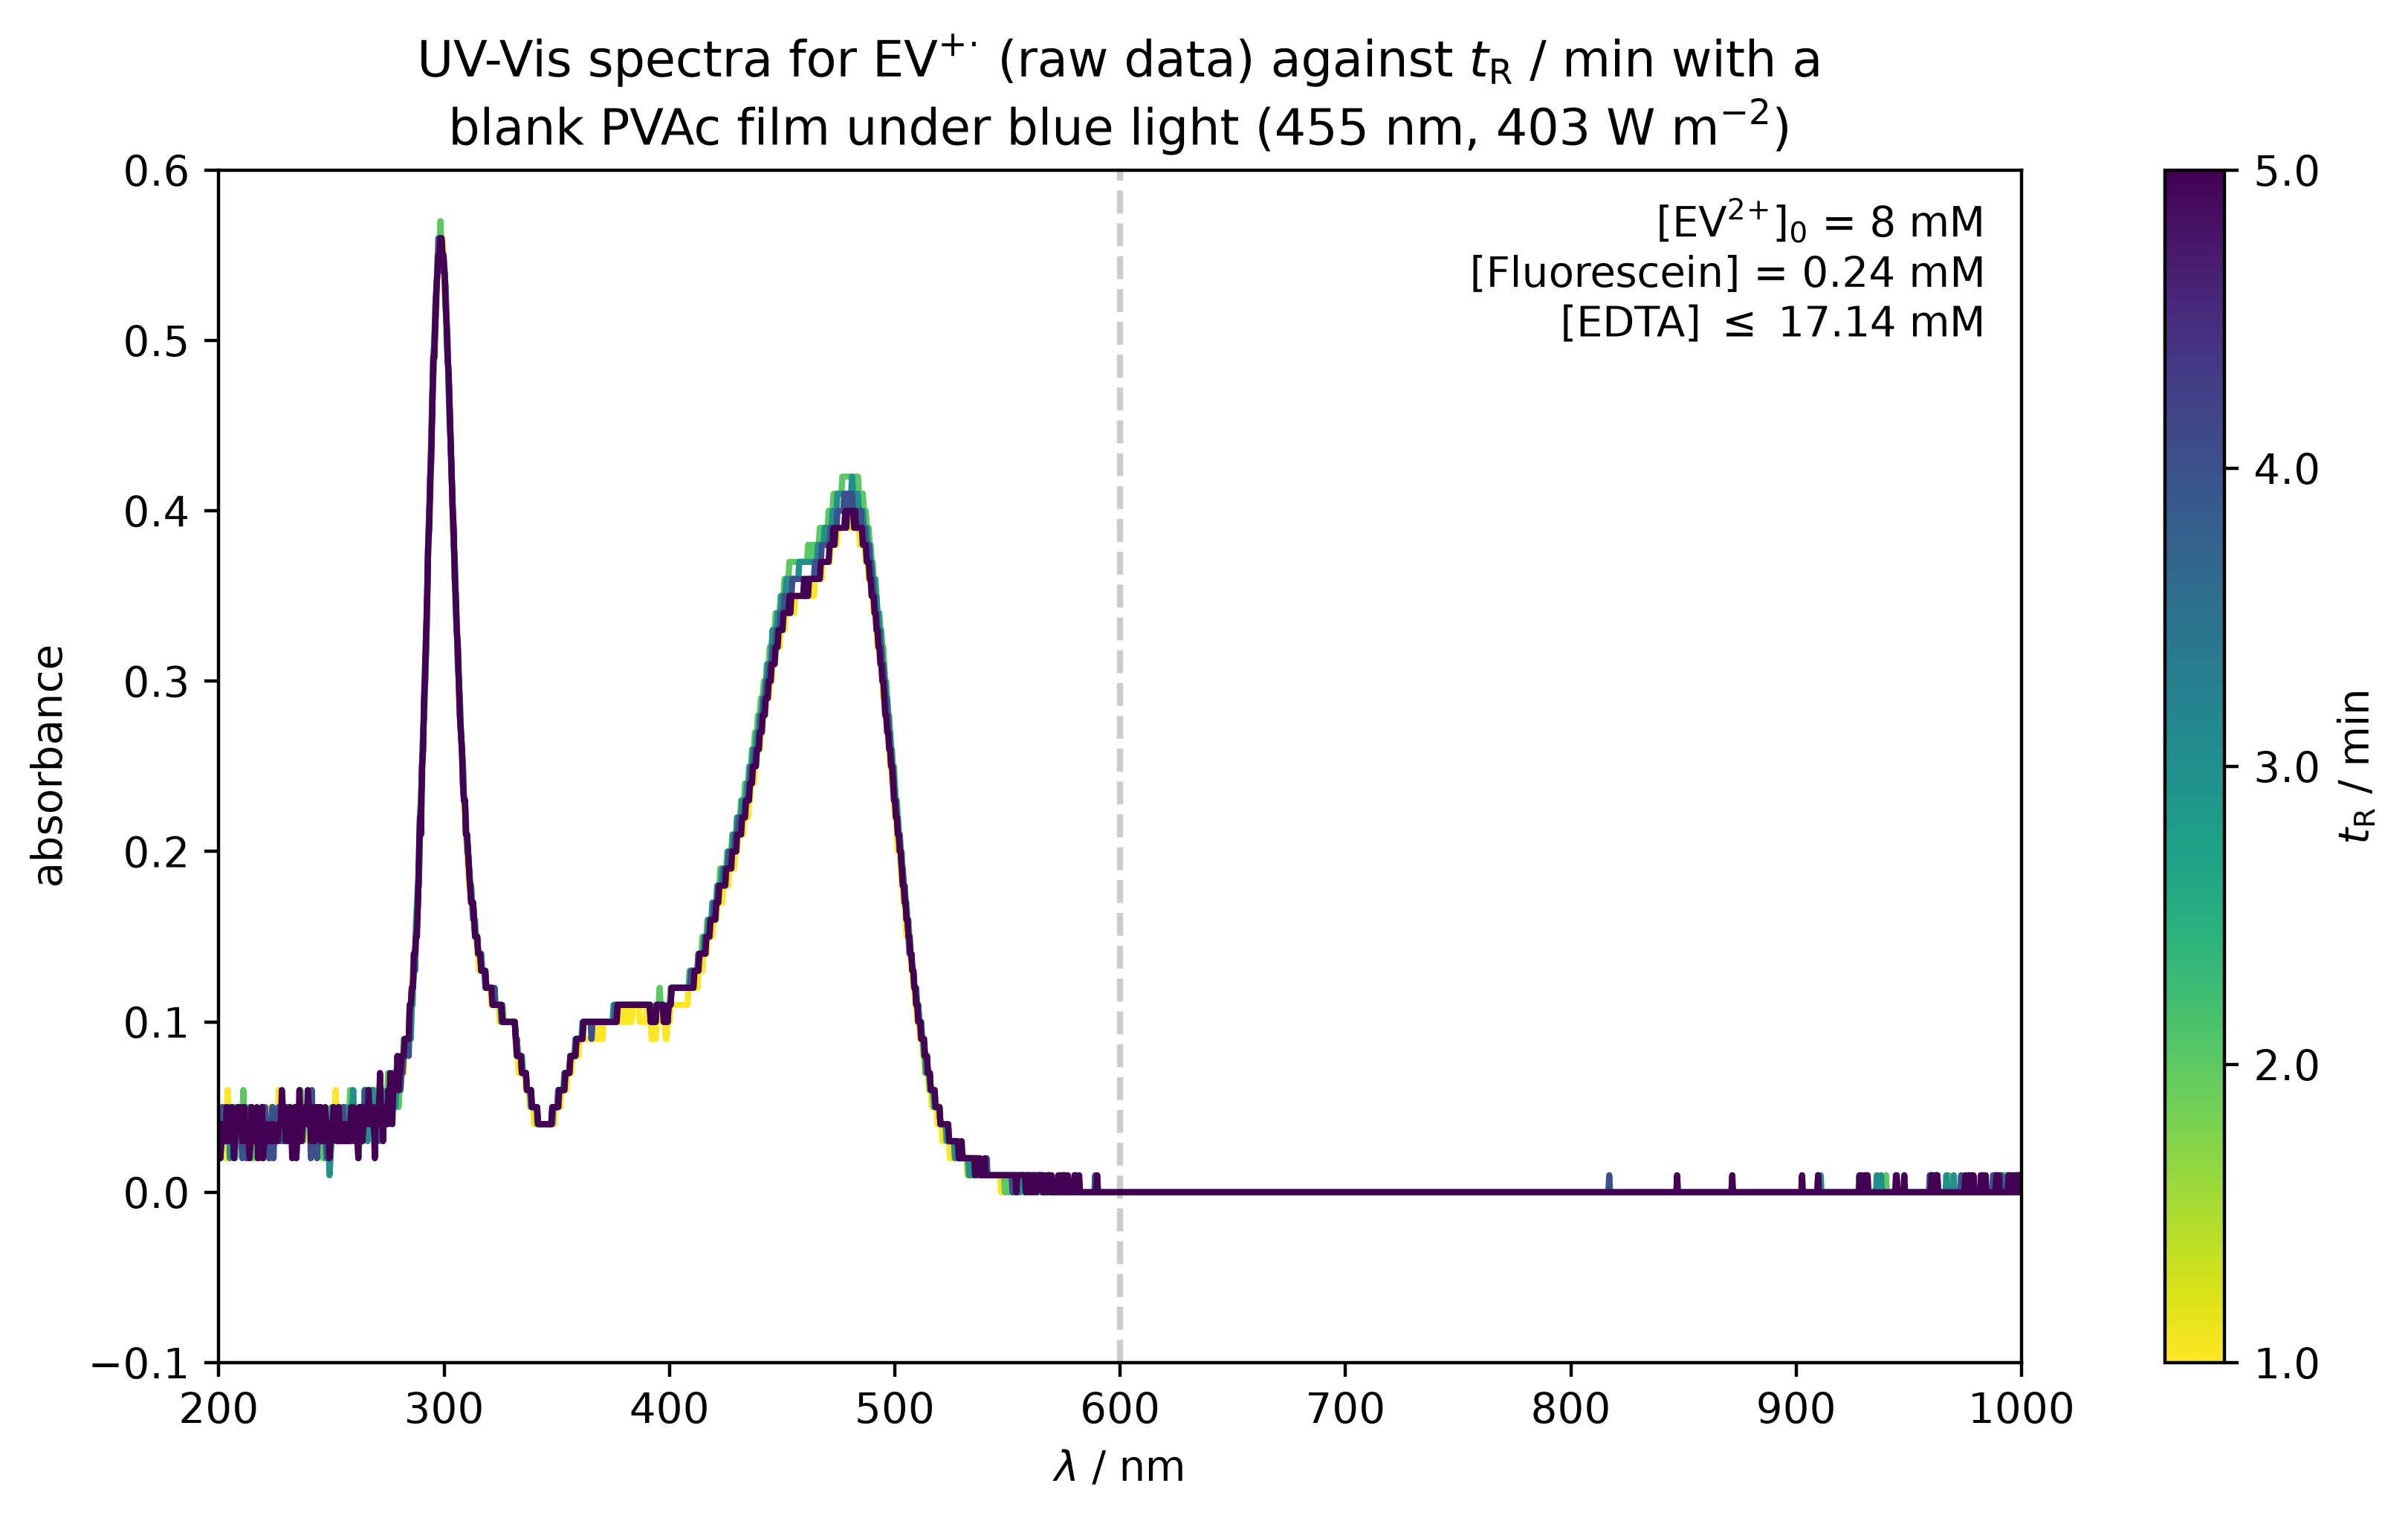

In [1]:
from lsmr_photocatalysis import ContinuousFlow, FLOW_PARAMS
import numpy as np

"""
Continuous flow with reaction/LED/film and UV-Vis at opposite ends of a single 250 ul reactor chamber.
Flow rate changes according to flow scheme at different time points to change residence time tR.
Blue 455 nm irradiation at 28.6 mW.

Fluorescein EDTA trial 2 in flow.
- Higher eq EDTA.
- Took buffer solution as UV-Vis background, not initial reaction solution.

V(Fluorescein, 5 mM, pH 7 buffer) = 144 ul (0.24 mM),
V(EV2+, 30 mM, pH 7 buffer) = 800 ul (8 mM),
V(EDTA, saturated <25 mM, pH 7 buffer) = 2056 ul (<17.14 mM).
"""

data = '260730_Fluorescein_EV_EDTA_Blank_Blue_Flow_2' # data folder name

tRs = np.arange(60, 5*60+1, 60) # residence times/s for 1-5 min in 1 min intervals
points = ContinuousFlow.recpoints(tRs, *FLOW_PARAMS['250ul']) # time/s points to record absorbances
start = "15-07-00-000" # recorded start time, although forgot to start recording for the first few minutes 

c0 = 8e-3 # initial EV2+ concentration
details = '[Fluorescein] = 0.24 mM\n[EDTA] $\\leq$ 17.14 mM' # concentrations of other reagents

x = 'EVxantheneblue'
film = 'blank PVAc'
light = 'blue'
wavelength = 455e-9 # m
power = 28.6e-3 # W

expt = ContinuousFlow(data, tRs, points, start, c0, details, x, film, light, wavelength, power, correction=False)
expt.concvstimeplot()
expt.concvstimeplot(ln=True)
expt.detectorconcplot()
expt.detectorspectrumplot()
expt.spectrumvstimeplot()